# Faza 4b: Razvoj "Bank-Independent" modela (Alternativni Score)

Na podlagi povratnih informacij in predlogov želimo ustvariti model strojnega učenja, ki **ne bo uporabljal** značilk, ki so že neposredna ocena banke (kot npr. FICO ocena, obrestna mera 'int_rate', ali 'grade' in 'sub_grade' ocene). 

S tem poskušamo odkriti in ovrednotiti, kako dobro lahko napovemo neplačilo (default) izključno iz "surovih" prosto dostopnih podatkov uporabnika, preden banka sploh formalno izračuna svojo birokratsko oceno tveganja.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Včitavanje finaliziranih podatkov iz Faz 1 do 3
train = pd.read_csv('../data/train_final.csv')
test = pd.read_csv('../data/test_final.csv')

# Ugotovimo ime ciljne spremenljivke
target_col = [col for col in train.columns if 'loan_status' in col.lower()][0]


bank_features = [col for col in train.columns if any(x in col.lower() for x in ['fico', 'grade', 'int_rate'])]

print("Odstranjeni bančno-odvisni atributi:\n", bank_features)

# Generiranje X in y brez tarče in brez bančnih ocen
X_train = train.drop(columns=[target_col] + bank_features)
X_test = test.drop(columns=[target_col] + bank_features)

y_train = train[target_col].astype(int)
y_test = test[target_col].astype(int)

print(f"\nNove trening dimenzije X (brez {len(bank_features)} bančnih ocen):", X_train.shape)

Odstranjeni bančno-odvisni atributi:
 ['sub_grade', 'int_rate', 'grade', 'fico_avg']

Nove trening dimenzije X (brez 4 bančnih ocen): (16000, 63)


## 1. Neodvisni model Logistične Regresije

--- Neodvisna Logistična Regresija (Tuned Threshold: 0.4) ---
              precision    recall  f1-score   support

           0       0.89      0.27      0.41      3201
           1       0.23      0.86      0.36       799

    accuracy                           0.39      4000
   macro avg       0.56      0.56      0.38      4000
weighted avg       0.75      0.39      0.40      4000



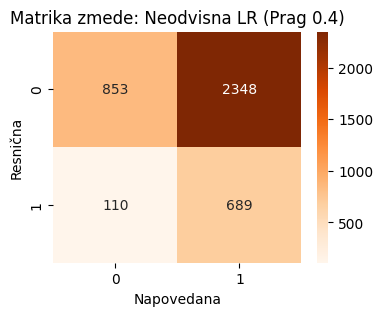

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# Logistična regresija (Tuning ni drastično potreben, le nastavitev praga)
lr_indep = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_indep.fit(X_train, y_train)

# Dobimo verjetnosti za razred 1
lr_probs = lr_indep.predict_proba(X_test)[:, 1]


THRESHOLD_LR = 0.40
lr_preds_tuned = (lr_probs >= THRESHOLD_LR).astype(int)

print(f"--- Neodvisna Logistična Regresija (Tuned Threshold: {THRESHOLD_LR}) ---")
print(classification_report(y_test, lr_preds_tuned))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, lr_preds_tuned), annot=True, fmt='d', cmap='Oranges')
plt.title(f"Matrika zmede: Neodvisna LR (Prag {THRESHOLD_LR})")
plt.xlabel("Napovedana")
plt.ylabel("Resnična")
plt.show()

## 2. Neodvisni model XGBoost


--- Neodvisni XGBoost (Tuned HParams + Threshold: 0.4) ---
              precision    recall  f1-score   support

           0       0.89      0.33      0.48      3201
           1       0.24      0.83      0.37       799

    accuracy                           0.43      4000
   macro avg       0.56      0.58      0.42      4000
weighted avg       0.76      0.43      0.46      4000



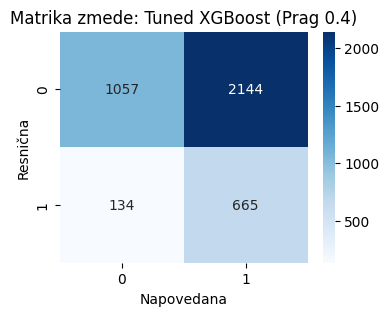

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Matematični parameter proti nesimetriji
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()


xgb_indep = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=150,
    max_depth=3,                 # Tuned: prepreči, da se uči šuma!
    subsample=0.8,               # Tuned: vsako drevo vidi le 80% vrstic
    colsample_bytree=0.8,        # Tuned: vsako drevo vidi le 80% stolpcev
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_indep.fit(X_train, y_train)

# Dobimo verjetnosti za razred 1
xgb_probs = xgb_indep.predict_proba(X_test)[:, 1]

THRESHOLD_XGB = 0.40
xgb_preds_tuned = (xgb_probs >= THRESHOLD_XGB).astype(int)

print(f"\n--- Neodvisni XGBoost (Tuned HParams + Threshold: {THRESHOLD_XGB}) ---")
print(classification_report(y_test, xgb_preds_tuned))

plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, xgb_preds_tuned), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matrika zmede: Tuned XGBoost (Prag {THRESHOLD_XGB})")
plt.xlabel("Napovedana")
plt.ylabel("Resnična")
plt.show()

## 3. Izvoz novih modelov za Streamlit aplikacijo
Za pravilno delovanje aplikacije moramo shraniti tudi točen seznam atributov obeh cevovodov, da bo Streamlit pravilno sestavil vektor za novega uporabnika.

In [ ]:
import os
import joblib
os.makedirs('../models', exist_ok=True)

# Shramba modelov
joblib.dump(lr_indep, '../models/lr_independent_model.pkl')
joblib.dump(xgb_indep, '../models/xgb_independent_model.pkl')

# Izračun AUC metrike za izpis
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr_indep = auc(fpr_lr, tpr_lr)

print(f"[✔] Neodvisni model Logistične Regresije (AUC: {auc_lr_indep:.2f}) uspešno shranjen v '../models/lr_independent_model.pkl'")
print("[✔] Neodvisni XGBoost model uspešno shranjen v '../models/xgb_independent_model.pkl'")


joblib.dump(list(X_train.columns), '../models/independent_features.pkl')

original_columns = list(train.drop(columns=[target_col]).columns)
joblib.dump(original_columns, '../models/dependent_features.pkl')

print("[✔] Seznam upoštevanih atributov (features list) uspesno shranjen za Streamlit aplikacijo.")

[✔] Neodvisni model Logistične Regresije (AUC: 0.63) uspešno shranjen v '../models/lr_independent_model.pkl'
[✔] Neodvisni XGBoost model uspešno shranjen v '../models/xgb_independent_model.pkl'
[✔] Seznam upoštevanih atributov (features list) uspesno shranjen za Streamlit aplikacijo.
